# Practica 04: Analisis de Datos Exploratorios con Python y jupiter Notebook en un Dataset de productos de Amazon Store

**Programa de Estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analitica de Datos para Negocios Digitales  \
**Docente:** M.T.I Marco A. Ramirez Hernandez \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparacion de los Datos 

**Nombre:** Karol Janeeth Gonzalez Vargas\
**Matricula:** 230323  \
**Grado y grupo:** 9°A IEVND 

<div style="background: linear-gradient(135deg, #288BC7 0%, #232F3E 100%);
padding: 30px; border-radius: 15px; text-align: center;
margin-bottom: 20px;">

<h1 style="color: white; font-size: 2.2em; margin: 0;">
🛒 Productos de Amazon Store – Análisis Exploratorio de Datos Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #FFD700; font-size: 1.1em; margin-top: 10px;">
Predicción de Precios · Análisis de Categorías · Ingeniería de Funcionalidades · Comparación de Modelos
</p>

</div>

---

## 📋 Tabla de Contenidos 
| # | Seccion | Descripcion |
|---|---|---|
| 1 | [Instalaciones & Carga de Datos](#s1) | Librerías, carga del CSV, primeros comandos de estructura |
| 2 | [Diccionario de Datos](#s2) | Explicaciondel contenido de columnas y calcular que 1% de datos faltantes |
| 3 | [Limpieza de Datos](#s3) | Aplicacion de metodos basicos de limpieza(eliminacion duplicadas, agrupacion, datos nulos) |
| 4 | [Ingenieria de Caracteristicas](#s4) | Características de texto, indicadores de categoría, niveles de precios |
| 5 | [Análisis univariado](#s5) | Distribuciones, valores atipicos, pruebas de normalidad|
| 6 | [Análisis de categorías ](#s6) | Top categorias,precio por categoria|
| 7 | [Análisis de disponibilidad](#s7) |Patrones delestado de stock |
| 8 | [Análisis de correlación y bivariado](#s8) | Heatmap,grafico de dispersion |


## 1. Instalaciones & Carga de Datos 🔧 <a id='s1'></a> 

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [15]:
# =============================================
# SECTION 1 - Setup & Data  Loading
# =============================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as ptl
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy.stats import shapiro

#ML - Machine Learning - Entrenamiento de modelos matematicos para predecir en este caso precios 
from sklearn.preprocessing import LabelEncoder, StandardScaler

print(f'✅ Pandas : {pd.__version__}')
print(f'✅ NumPy : {np.__version__}')
print('✅ Todas las librerías cargaron con éxito!')


✅ Pandas : 2.3.3
✅ NumPy : 2.3.5
✅ Todas las librerías cargaron con éxito!


In [16]:
# Load dataset
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f'📦 Shape: {df_raw.shape}')
print(f'📋 Columns: {df_raw.columns.tolist()}')

df_raw.head(3)

📦 Shape: (1448, 17)
📋 Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2. Diccionario de Datos del Data Frame   <a id='s2'></a> 

In [17]:
# Colum dictionary 
col_info = {
    'rl'               :'URL del producto en Amazon.in',
    'asin'             :'Numero Estandarizado de Indentificacion por Amazon(unique ID)',
    'name'             :'Nombre o Titulo del Producto',
    'overview'         :'Breve reseña del Producto(mayoria vacio [])',
    'price'            :'Precio como string (e.g "1,600.00")',
    'currency'         :'Codigo de Divisa(Todas en INR)',
    'availability'     :'Texto del Satatus del stock(Inventario)',
    'brand'            :'Nombre de la Marca/Autor',
    'about_item'       :'Detalles/Especificaciones(mayoria faltante)',
    'img_source'       :'URLs de Imagenes del producto',
    'description'      :'Descripcion detallada y completa(mayoria faltante)',
    'specifications'   :'Especificaciones Tecnicas',
    'primary_category' :'Categoria Principal(Libros, Kindle, Deportes...)',
    'category_1'       :'Subcategoria de Nivel 1',
    'category_2'       :'Subcategoria de Nivel 2)',
    'category_3'       :'Subcategoria de Nivel 3',
    'breadcrumbs'      :'Ruta de Categorias',
}
print('📖 Diccionario por columnas:')

for col, desc in col_info.items():
    missing_pct = df_raw[col].isnull().mean() * 100
    print(
        f' {col:20s} |' 
        f' {desc[:45]:45s} |'
        f' Missing: {missing_pct:.0f}%'
    )


📖 Diccionario por columnas:
 rl                   | URL del producto en Amazon.in                 | Missing: 0%
 asin                 | Numero Estandarizado de Indentificacion por A | Missing: 0%
 name                 | Nombre o Titulo del Producto                  | Missing: 1%
 overview             | Breve reseña del Producto(mayoria vacio [])   | Missing: 0%
 price                | Precio como string (e.g "1,600.00")           | Missing: 24%
 currency             | Codigo de Divisa(Todas en INR)                | Missing: 24%
 availability         | Texto del Satatus del stock(Inventario)       | Missing: 33%
 brand                | Nombre de la Marca/Autor                      | Missing: 1%
 about_item           | Detalles/Especificaciones(mayoria faltante)   | Missing: 92%
 img_source           | URLs de Imagenes del producto                 | Missing: 1%
 description          | Descripcion detallada y completa(mayoria falt | Missing: 92%
 specifications       | Especificaciones Te

## 3.Limpieza de Datos <a id='s3'></a> 

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parseas el precio strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [18]:
# ============================================================
# SECTION 3 — Data Cleaning
# ============================================================
df = df_raw.copy()

# ── Parse price ─────────────────────────────────────────────
def clean_price(p):
    if pd.isna(p): return np.nan
    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)
    return float(m.group()) if m else np.nan

df['price_clean'] = df['price'].apply(clean_price)

# ── Standardise availability ─────────────────────────────────
def clean_availability(a):
    if pd.isna(a): return 'Unknown'
    a = str(a).strip().lower()
    if 'in stock' in a:          return 'In Stock'
    if 'unavailable' in a:       return 'Unavailable'
    if '1 to 3' in a:            return 'Ships 1-3 weeks'
    if '4 to 5' in a or '6 to' in a or '9 to' in a: return 'Ships 4-14 days'
    if '13 to 14' in a or '2 to 3 weeks' in a:      return 'Ships 2+ weeks'
    if 'only' in a and 'left' in a: return 'Low Stock'
    if '2 to 3 days' in a or '1 to 2 days' in a:    return 'Ships 1-3 days'
    return 'Other'

df['avail_clean'] = df['availability'].apply(clean_availability)

# ── Text length features ─────────────────────────────────────
df['name_length']  = df['name'].fillna('').str.len()
df['name_words']   = df['name'].fillna('').str.split().str.len()
df['has_brand']    = df['brand'].notna().astype(int)
df['has_desc']     = df['description'].notna().astype(int)
df['has_specs']    = df['specifications'].notna().astype(int)

# ── Duplicate check ──────────────────────────────────────────
dupes = df.duplicated(subset='asin').sum()
print(f'✅ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✅ Duplicate ASINs: {dupes}')
print(f'✅ Availability categories: {df["avail_clean"].value_counts().to_dict()}')
df[['name','price_clean','avail_clean','primary_category','name_length']].head(5)

✅ Price parsed: 1,096 / 1,448 products
✅ Duplicate ASINs: 8
✅ Availability categories: {'In Stock': 609, 'Unknown': 482, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 115, 'Ships 2+ weeks': 80, 'Other': 25, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


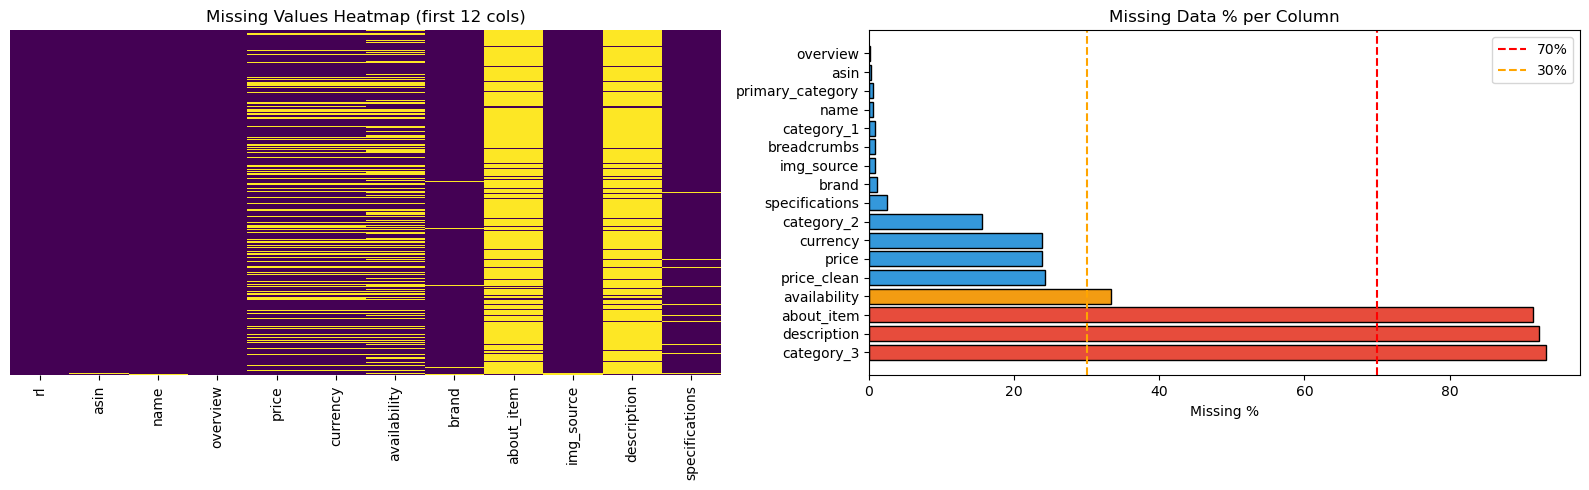

                  Missing Count  Missing Pct
category_3                 1351         93.3
description                1336         92.3
about_item                 1325         91.5
availability                482         33.3
price_clean                 352         24.3
price                       346         23.9
currency                    346         23.9
category_2                  226         15.6
specifications               36          2.5
brand                        16          1.1
img_source                   11          0.8
breadcrumbs                  12          0.8
category_1                   11          0.8
name                          8          0.6
primary_category              7          0.5
asin                          4          0.3
overview                      2          0.1


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct': (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis',
    ax=axes[0]
)
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]

if not mv.empty:
    colors_mv = [
        '#e74c3c' if v > 70 else '#f39c12' if v > 30 else '#3498db'
        for v in mv['Missing Pct']
    ]

    axes[1].barh(
        mv.index,
        mv['Missing Pct'],
        color=colors_mv,
        edgecolor='black'
    )
    axes[1].axvline(70, color='red', linestyle='--', label='70%')
    axes[1].axvline(30, color='orange', linestyle='--', label='30%')
    axes[1].legend()

axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4.Ingenieria de Caracteristicas (Feature Engineering) <a id='s4'></a> 

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ea60; border-radius:5px; color: #0066cc;">
<b>Ejemplo Cotidiano:</b>Un agente inmobiliario no solo utiliza ls metros cuadrados bruts, si no que tambien considera la ubicacion, la antiguedad y el estado. nosotros hacemos lo mismo: extraemos informacion mas valiosa del texto sin procesar y las categorias....
</div>

In [20]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

print(f'✅ Total features engineered: {len(df.columns)}')
print('\nPrice tier distribution:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)

✅ Total features engineered: 39

Price tier distribution:
price_tier
1_budget     105
2_low        285
3_mid        320
4_premium    260
5_luxury     126
Unknown      352


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5.Análisis univariado (Univariate Analysis) <a id='s5'></a> 

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Cómo es la distribución de precios? ¿Hay valores atípicos? ¿Los datos están sesgados?
</div>

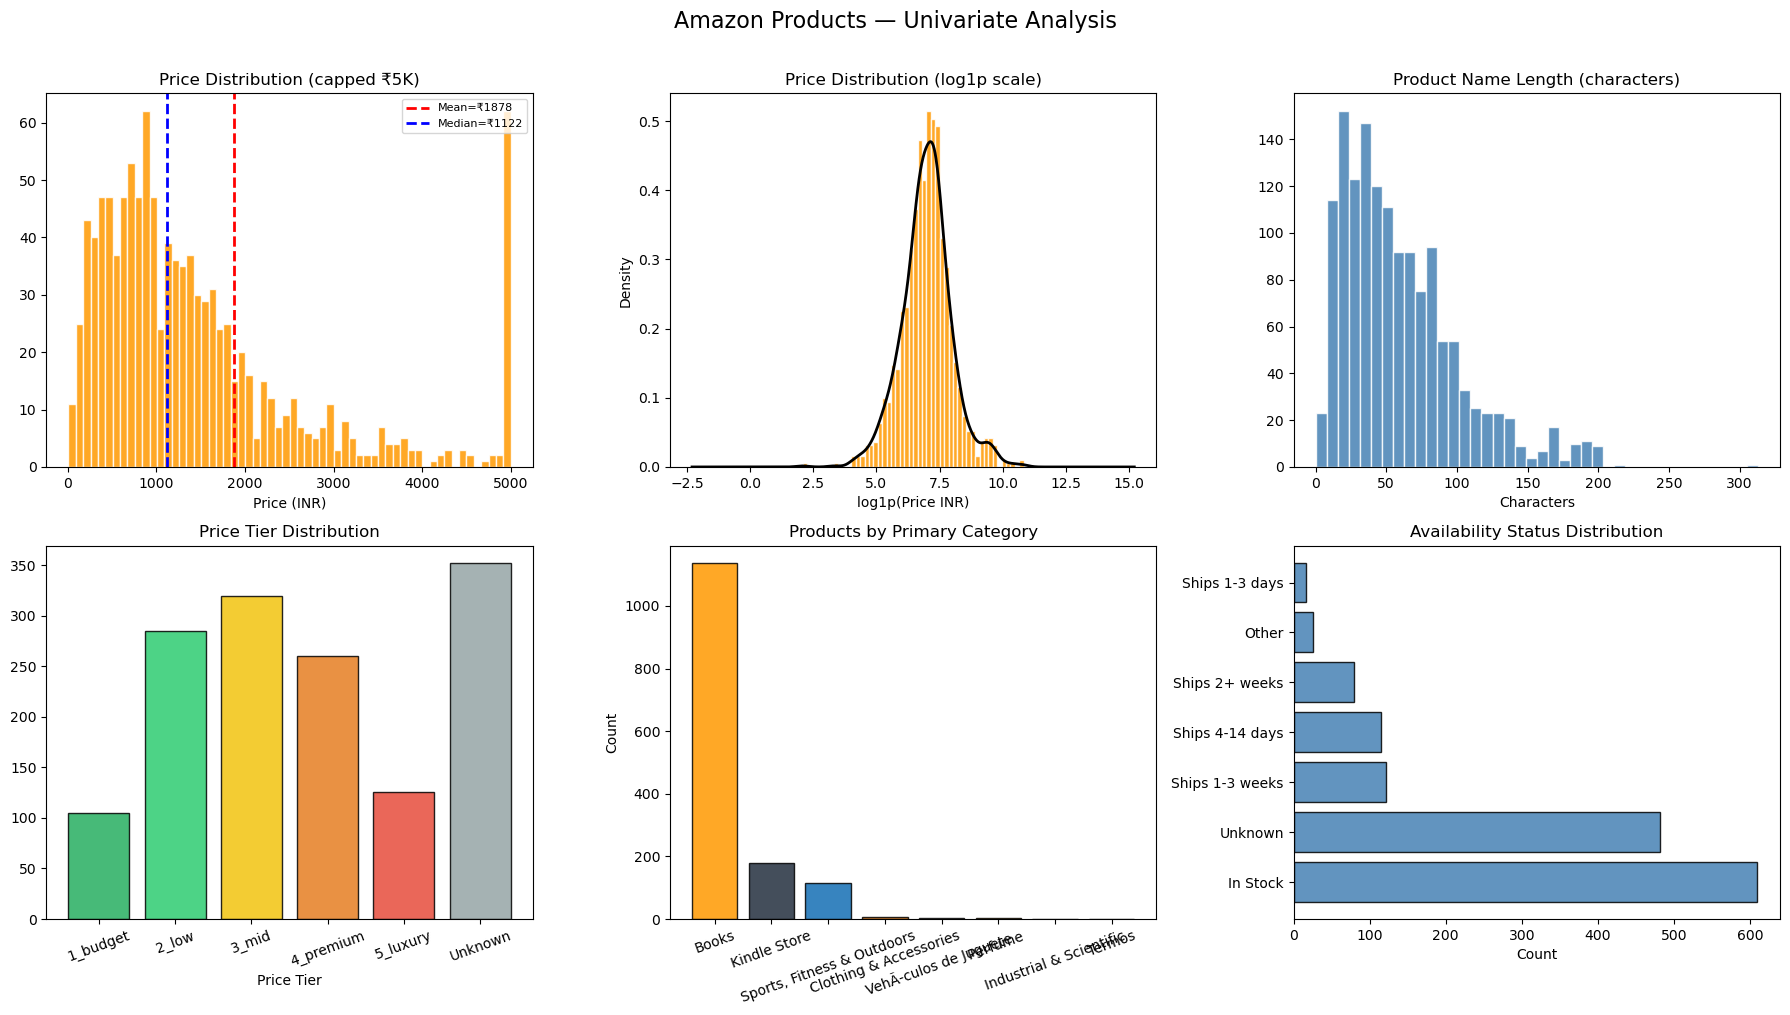

Shapiro-Wilk (log price, n=500): stat=0.9854, p=0.000066
Price is still non-normal after log transform

Price stats (INR):
count     1089.00
mean      1878.04
std       3337.00
min          7.00
25%        612.00
50%       1122.00
75%       1849.00
max      50555.00


In [21]:
# ============================================================
# SECTION 4 — Univariate Analysis
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Price raw
axes[0,0].hist(df_priced['price_clean'].clip(upper=5000), bins=60,
               color='#FF9900', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df_priced['price_clean'].mean(), color='red', linestyle='--',
                  lw=2, label=f'Mean=₹{df_priced["price_clean"].mean():.0f}')
axes[0,0].axvline(df_priced['price_clean'].median(), color='blue', linestyle='--',
                  lw=2, label=f'Median=₹{df_priced["price_clean"].median():.0f}')
axes[0,0].set_title('Price Distribution (capped ₹5K)')
axes[0,0].set_xlabel('Price (INR)'); axes[0,0].legend(fontsize=8)

# Price log
axes[0,1].hist(df_priced['log_price'], bins=50, color='#FF9900',
               edgecolor='white', alpha=0.85, density=True)
df_priced['log_price'].plot.kde(ax=axes[0,1], color='black', lw=2)
axes[0,1].set_title('Price Distribution (log1p scale)')
axes[0,1].set_xlabel('log1p(Price INR)')

# Name length
axes[0,2].hist(df['name_length'], bins=40, color='steelblue',
               edgecolor='white', alpha=0.85)
axes[0,2].set_title('Product Name Length (characters)')
axes[0,2].set_xlabel('Characters')

# Price tier
tier_counts = df['price_tier'].value_counts().sort_index()
tier_colors = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#95a5a6']
axes[1,0].bar(tier_counts.index, tier_counts.values,
              color=tier_colors[:len(tier_counts)], edgecolor='black', alpha=0.85)
axes[1,0].set_title('Price Tier Distribution')
axes[1,0].set_xlabel('Price Tier'); axes[1,0].tick_params(axis='x', rotation=20)

# Primary category
cat_counts = df['primary_category'].value_counts()
axes[1,1].bar(cat_counts.index, cat_counts.values,
              color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
              edgecolor='black', alpha=0.85)
axes[1,1].set_title('Products by Primary Category')
axes[1,1].set_ylabel('Count'); axes[1,1].tick_params(axis='x', rotation=20)

# Availability
avail_counts = df['avail_clean'].value_counts()
axes[1,2].barh(avail_counts.index, avail_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)
axes[1,2].set_title('Availability Status Distribution')
axes[1,2].set_xlabel('Count')

plt.suptitle('Amazon Products — Univariate Analysis', fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

# Normality test
stat, p = shapiro(df_priced['log_price'].sample(min(500, len(df_priced)), random_state=42))
print(f'Shapiro-Wilk (log price, n=500): stat={stat:.4f}, p={p:.6f}')
print(f'Price is {"normally distributed after log transform" if p > 0.05 else "still non-normal after log transform"}')
print(f'\nPrice stats (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

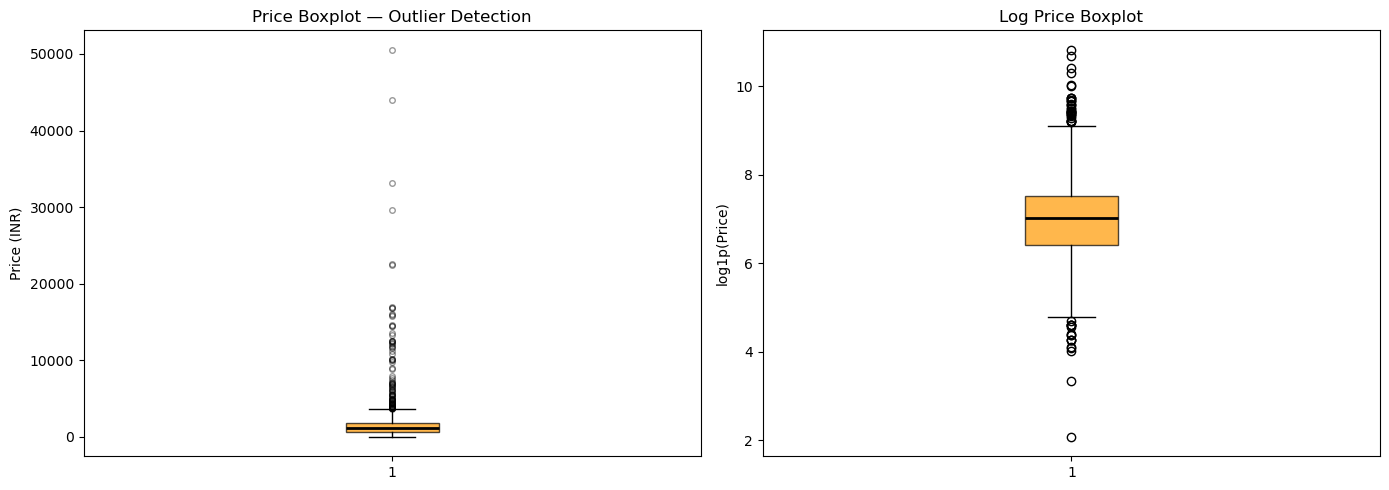

IQR method outliers: 93 (8.5%)
Price range (non-outlier): ₹-1244 – ₹3704

Top 10 most expensive products:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graphics Series)     29633.00                 

In [22]:
# Outlier analysis — boxplot and IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(df_priced['price_clean'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2),
                flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red'))
axes[0].set_title('Price Boxplot — Outlier Detection')
axes[0].set_ylabel('Price (INR)')

axes[1].boxplot(df_priced['log_price'], patch_artist=True,
                boxprops=dict(facecolor='#FF9900', alpha=0.7),
                medianprops=dict(color='black', lw=2))
axes[1].set_title('Log Price Boxplot')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df_priced[(df_priced['price_clean'] < Q1 - 1.5*IQR) |
                      (df_priced['price_clean'] > Q3 + 1.5*IQR)]
print(f'IQR method outliers: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Price range (non-outlier): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')
print(f'\nTop 10 most expensive products:')
print(df_priced.nlargest(10, 'price_clean')[['name','price_clean','primary_category']].to_string(index=False))

## 6.Análisis de categorías (Category Analysis) <a id='s6'></a> 

<div style="background:#fff8e1; padding:12px; border-left:4px solid #FF9900; border-radius:5px; color: #0066cc;">
<b>Pregunta clave: </b> ¿Qué categorías tienen los precios más altos? ¿Qué subcategorías predominan? ¿Dónde se encuentra la mejor relación calidad-precio?
</div>

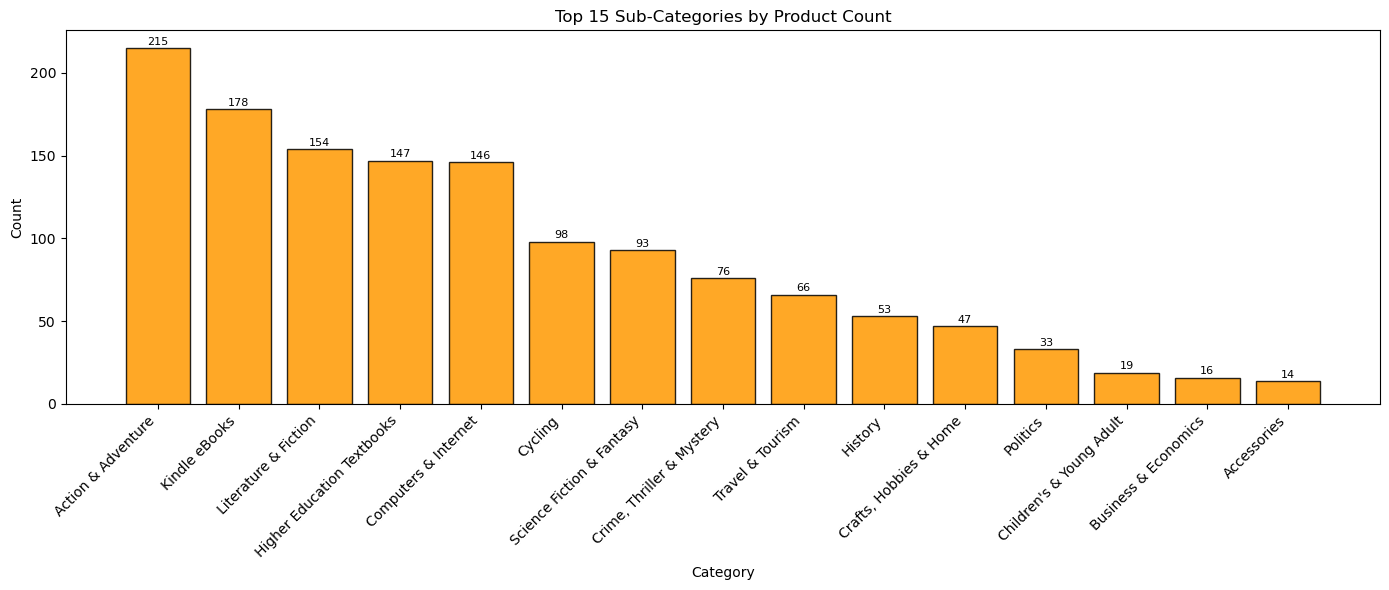

In [23]:
# ============================================================
# SECTION 5 — Category Analysis
# ============================================================
# Top 15 sub-categories by count
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))
bars = plt.bar(top15_cat1.index, top15_cat1.values,
               color='#FF9900', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, top15_cat1.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
             str(val), ha='center', fontsize=8)
plt.title('Top 15 Sub-Categories by Product Count')
plt.xlabel('Category'); plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

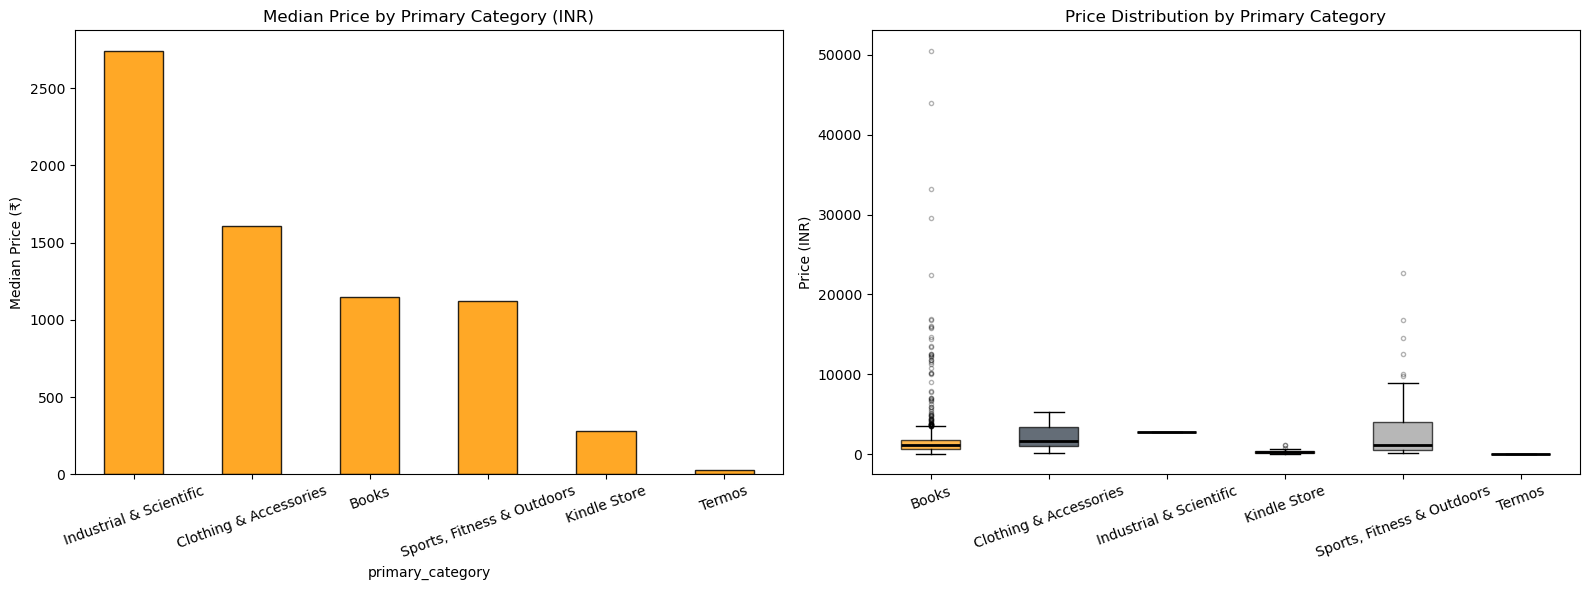

Price stats by primary category:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93
Termos                        27.0    27.0      1


In [30]:
# Price by primary category
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)
cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Primary Category (INR)')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=20)

# Boxplot
cat_groups = [df_priced[df_priced['primary_category']==c]['price_clean'].dropna()
              for c in cat_price.index]

bp = axes[1].boxplot(
    cat_groups,
    tick_labels=cat_price.index,  # ← cambio aquí
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

colors_cat = ['#FF9900','#232F3E','#146EB4','#E47911','#999']

for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Price Distribution by Primary Category')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Price stats by primary category:')
print(cat_price.to_string())

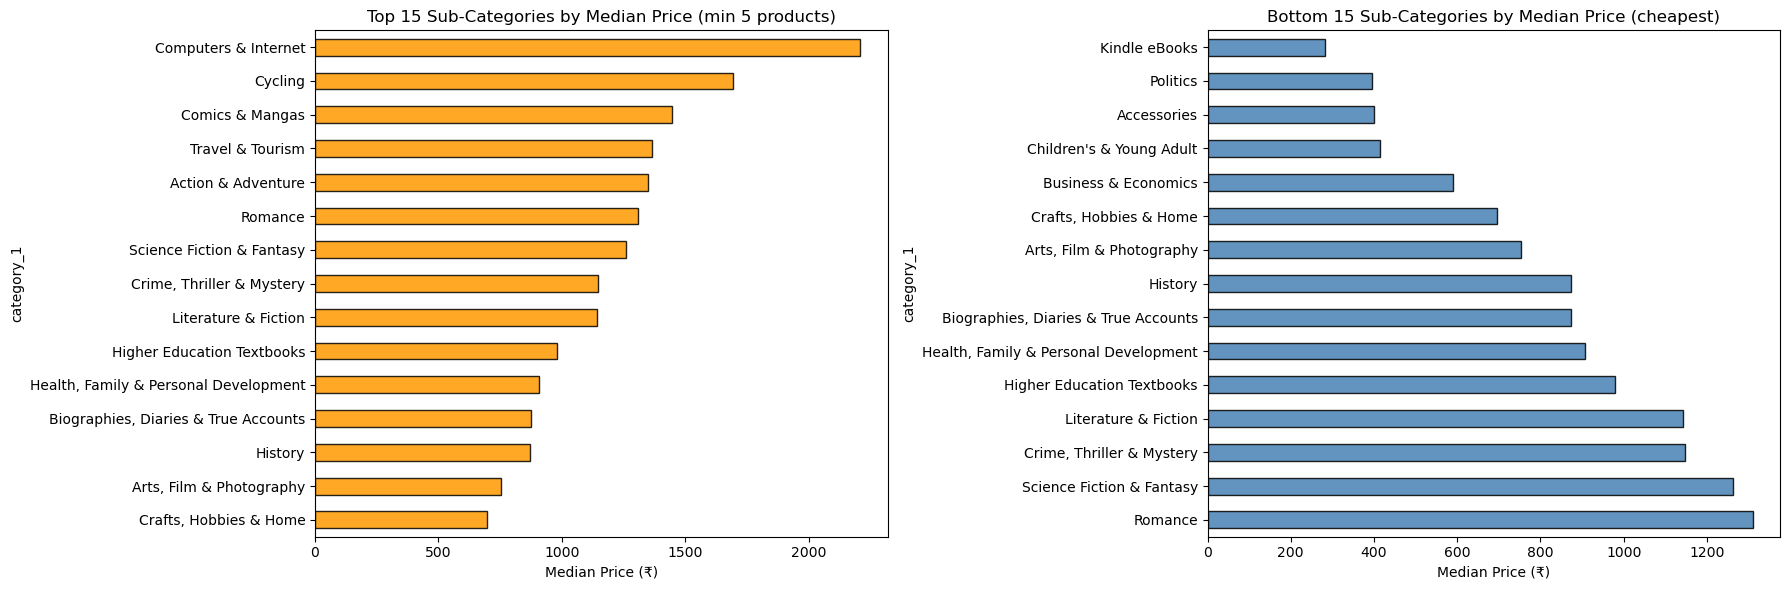

In [31]:
# Top 15 sub-categories by median price
top_cat1_price = (df_priced.groupby('category_1')['price_clean']
                  .agg(['median','count'])
                  .query('count >= 5')
                  .sort_values('median', ascending=False)
                  .head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Top 15 Sub-Categories by Median Price (min 5 products)')
axes[0].set_xlabel('Median Price (₹)')

# Bottom 15 (cheapest)
bottom_cat1 = (df_priced.groupby('category_1')['price_clean']
               .agg(['median','count'])
               .query('count >= 5')
               .sort_values('median')
               .head(15))
bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1], color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Bottom 15 Sub-Categories by Median Price (cheapest)')
axes[1].set_xlabel('Median Price (₹)')

plt.tight_layout(); plt.show()

## 7.Análisis de disponibilidad (Availability Analysis) <a id='s7'></a> 

<div style="background:#f0fff0; padding:12px; border-left:4px solid #27ae60; border-radius:5px; color: #0066cc;">
<b>Pregunta clave: </b> ¿Influye la disponibilidad en el precio? ¿Es más probable que los productos premium se agoten?
</div>

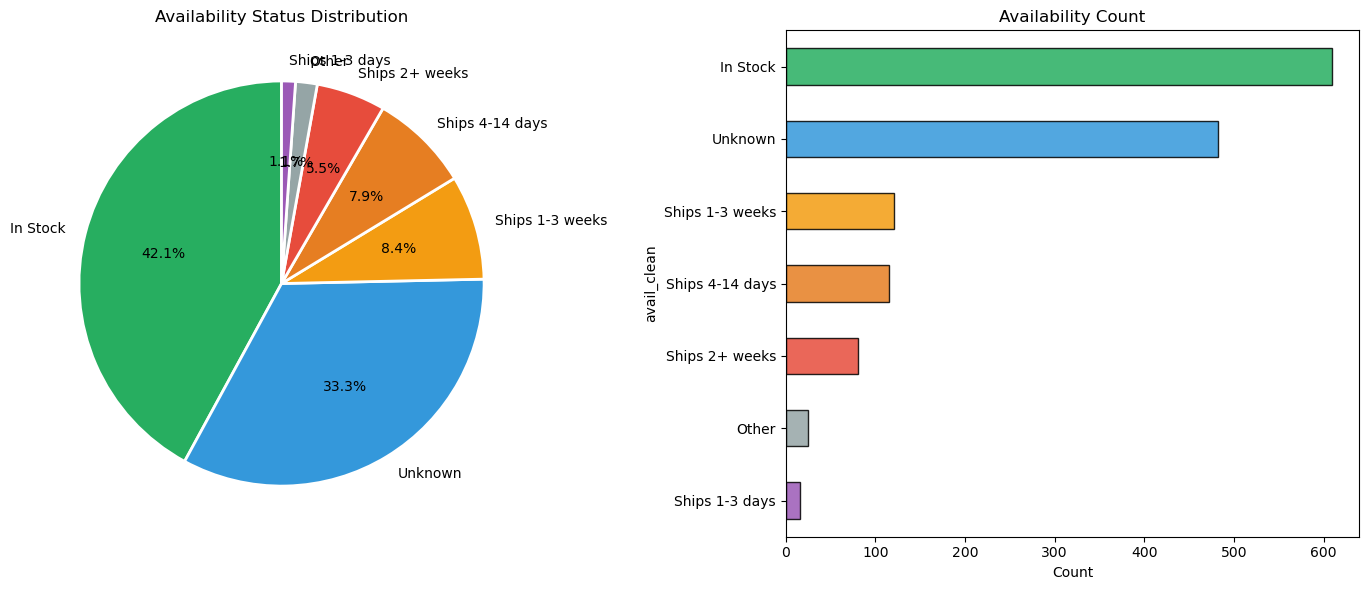

In [32]:
# ============================================================
# SECTION 6 — Availability Analysis
# ============================================================
avail_counts = df['avail_clean'].value_counts()
avail_colors = ['#27ae60','#3498db','#f39c12','#e67e22','#e74c3c','#95a5a6','#9b59b6','#1abc9c']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].pie(avail_counts.values, labels=avail_counts.index,
            colors=avail_colors[:len(avail_counts)],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Availability Status Distribution')

avail_counts.sort_values().plot.barh(
    ax=axes[1], color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black', alpha=0.85)
axes[1].set_title('Availability Count')
axes[1].set_xlabel('Count')

plt.tight_layout(); plt.show()

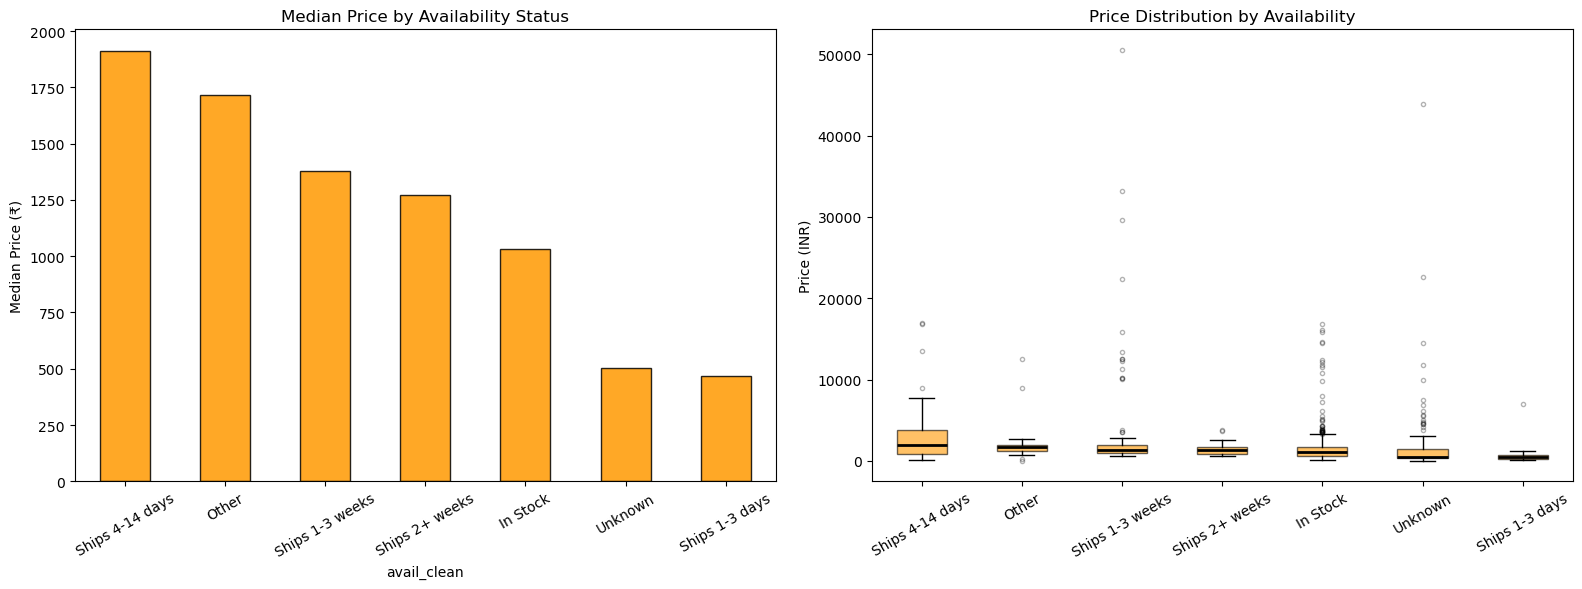

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2874.6    115
Other            1718.0  2343.6     21
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1031.0  1490.5    601
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [34]:
# Price by availability status

avail_price = (
    df_priced.groupby('avail_clean')['price_clean']
    .agg(['median', 'mean', 'count'])
    .round(1)
)

avail_price = (
    avail_price[avail_price['count'] >= 5]
    .sort_values('median', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
avail_price['median'].plot.bar(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)')
axes[0].tick_params(axis='x', rotation=30)

# Boxplot
avail_groups = [
    df_priced[df_priced['avail_clean'] == a]['price_clean'].dropna()
    for a in avail_price.index
]

bp = axes[1].boxplot(
    avail_groups,
    tick_labels=avail_price.index,  # corregido
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

for patch in bp['boxes']:
    patch.set_facecolor('#FF9900')
    patch.set_alpha(0.6)

axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Price by availability:')
print(avail_price.to_string())

## 8.Análisis de correlación y bivariado (Correlation & Bivariate Analysis) <a id='s8'></a> 

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #3498db; border-radius:5px; color: #0066cc;">
<b>Pregunta clave:</b> ¿Qué características están más correlacionadas con el precio? ¿La longitud del nombre predice el precio?
</div>

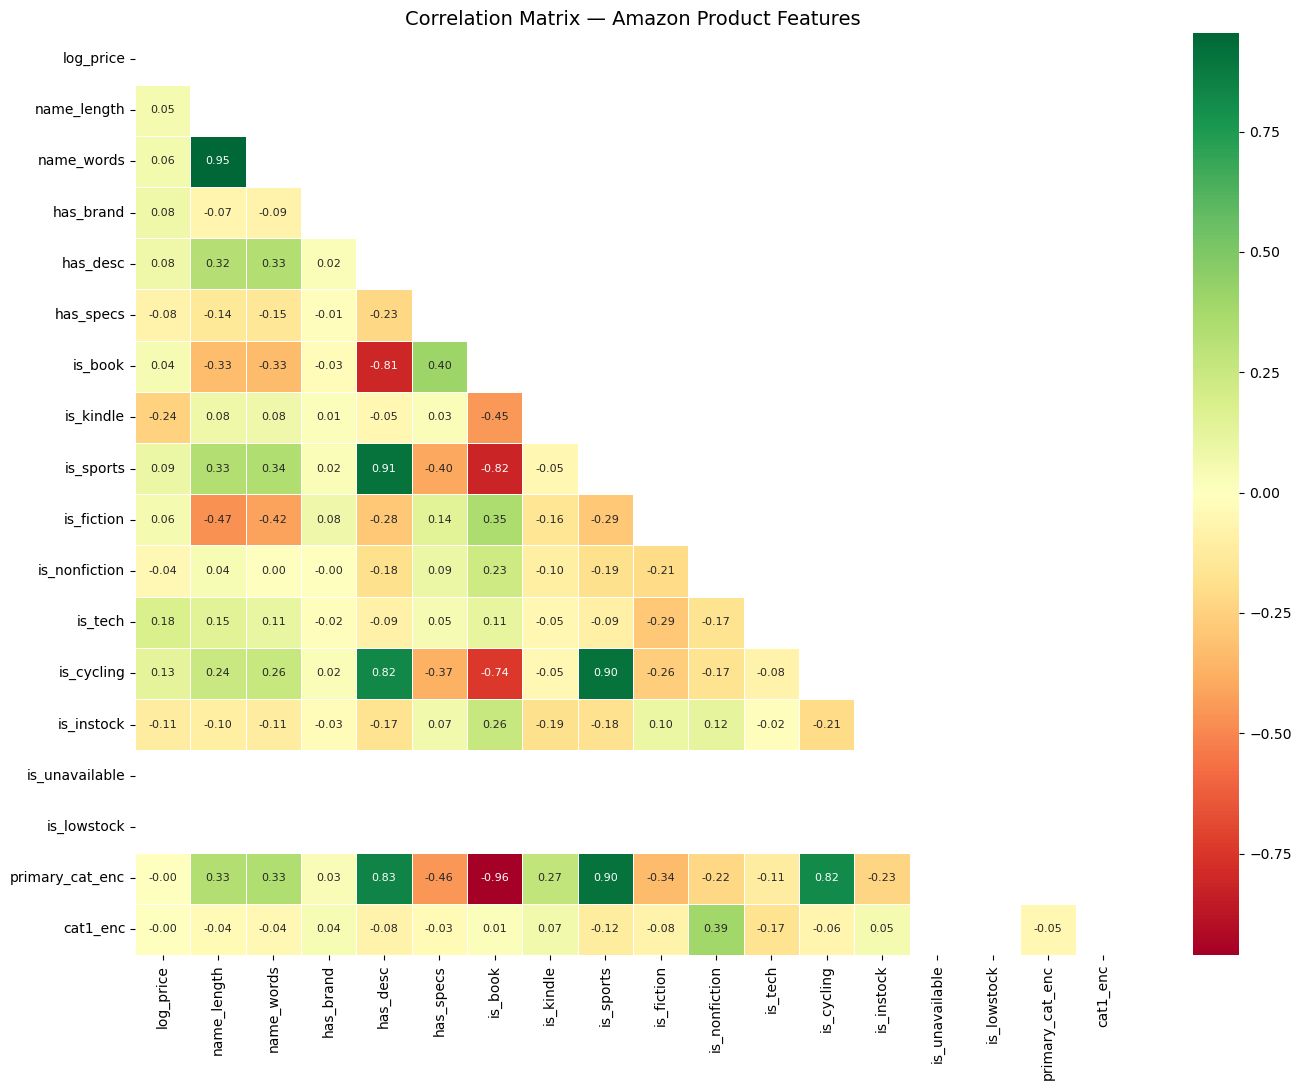

Top correlations with log_price:
is_tech            0.176684
is_cycling         0.126903
is_sports          0.092321
has_brand          0.082988
has_desc           0.081378
name_words         0.058492
is_fiction         0.055768
name_length        0.053223
is_book            0.043470
primary_cat_enc   -0.001162
cat1_enc          -0.002536
is_nonfiction     -0.041991
has_specs         -0.075614
is_instock        -0.108085
is_kindle         -0.244538
is_unavailable          NaN
is_lowstock             NaN


In [35]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

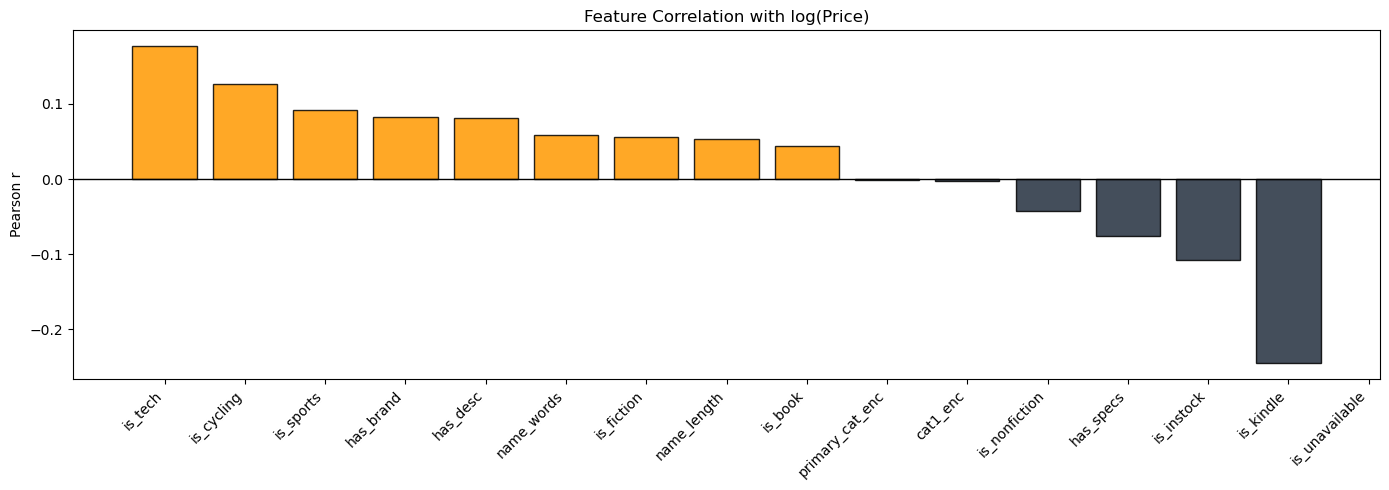

In [36]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

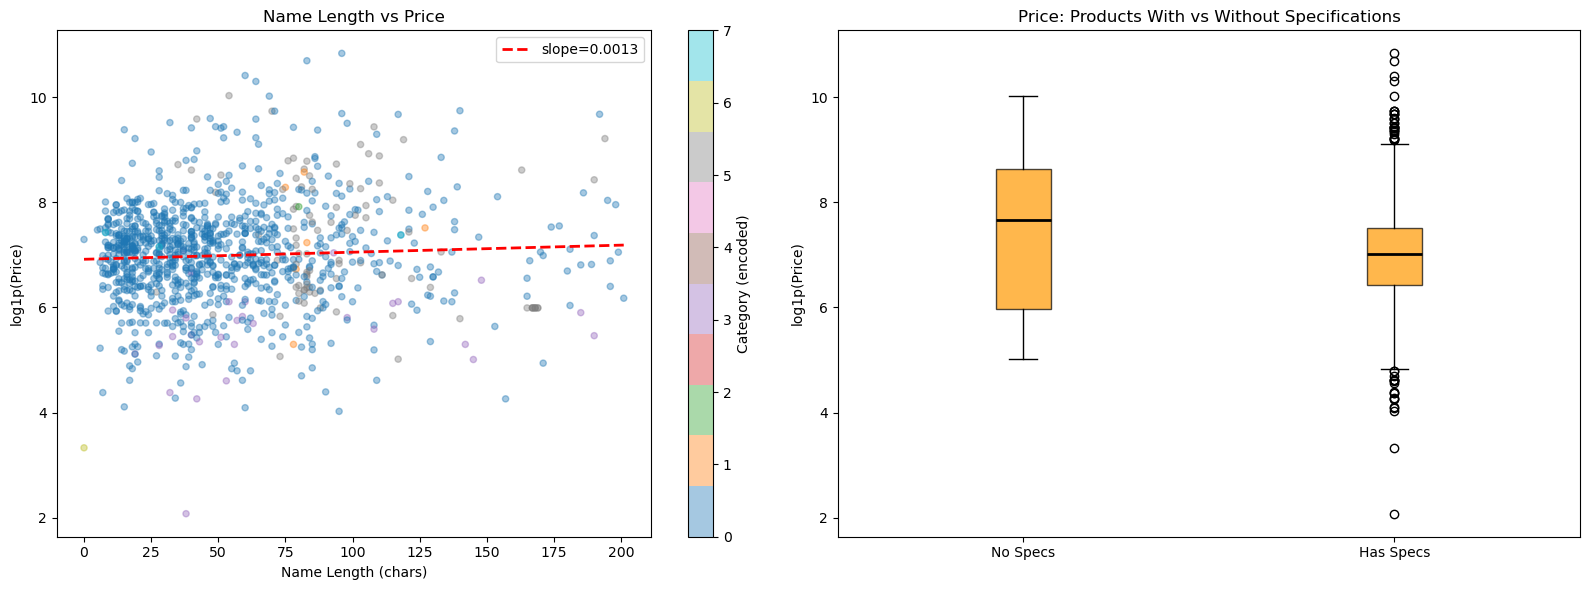

In [38]:
# Scatter: name length vs price
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(df_priced['name_length'], df_priced['log_price'],
                     c=df_priced['primary_cat_enc'], cmap='tab10',
                     alpha=0.4, s=20)
plt.colorbar(sc, ax=axes[0], label='Category (encoded)')
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x+b, 'r--', lw=2, label=f'slope={m:.4f}')
axes[0].set_xlabel('Name Length (chars)'); axes[0].set_ylabel('log1p(Price)')
axes[0].set_title('Name Length vs Price'); axes[0].legend()

# Price by has_specs
axes[1].boxplot(
    [np.log1p(df_priced[df_priced['has_specs']==0]['price_clean']),
     np.log1p(df_priced[df_priced['has_specs']==1]['price_clean'])],
    tick_labels=['No Specs', 'Has Specs'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)
axes[1].set_title('Price: Products With vs Without Specifications')
axes[1].set_ylabel('log1p(Price)')

plt.tight_layout(); plt.show()